# MScFE 610 Financial Econometrics — Group Work Project 1
**Group 14043**

- Ronald Wilson Howes
- Duong Trung Vo
- Bukunmi Akinyemi

This notebook contains the executable code and outputs for all six problems. Narrative answers and discussion appear in the accompanying PDF report.

---
## Problem 1 — Omitted Variable Bias

True model: $Y_i = \alpha + \beta x_i + \gamma w_i + \delta z_i + \varepsilon_i$  
Estimated (mis-specified) model: $Y_i = \alpha + \beta x_i + \gamma w_i + \mu_i$

Parts 1a–1c are conceptual and answered in the report. Part **1d** demonstrates the bias by simulation.

### 1d) Simulation: omitting a correlated regressor

In [21]:
import numpy as np
import statsmodels.api as sm

def omitted_variable_experiment(n, seed=42):
    np.random.seed(seed)
    # Z and X are correlated (X depends on Z)
    Z = np.random.normal(0, 1, n)
    X = 0.5 * Z + np.random.normal(0, 1, n)
    e = np.random.normal(0, 1, n)  # error independent of X and Z
    # True model: Y = 5 + 2*X + 3*Z + e
    Y = 5 + 2*X + 3*Z + e

    # Full (correct) model
    full = sm.OLS(Y, sm.add_constant(np.column_stack((X, Z)))).fit()
    # Omitted-variable model
    omitted = sm.OLS(Y, sm.add_constant(X)).fit()
    return full.params[1], omitted.params[1]

for n in [100, 1000, 10000, 100000]:
    b_full, b_omit = omitted_variable_experiment(n)
    print(f"n = {n:>6}  | beta (full) = {b_full:.4f} | beta (omitted) = {b_omit:.4f}")

n =    100  | beta (full) = 1.9877 | beta (omitted) = 2.9411
n =   1000  | beta (full) = 1.9898 | beta (omitted) = 3.1041
n =  10000  | beta (full) = 2.0268 | beta (omitted) = 3.2244
n = 100000  | beta (full) = 1.9962 | beta (omitted) = 3.2106


**Observation.** With X and Z correlated (Cov(X,Z) ≠ 0), omitting Z biases the estimate of β upward — toward roughly 3.22 instead of the true 2.0. Increasing the sample size does **not** fix the bias: OLS remains *inconsistent* when a relevant correlated regressor is omitted, because the omitted variable is absorbed into the error term and becomes correlated with X, violating the exogeneity assumption $E[\mu \mid X] = 0$. The bias formula is $\text{bias}(\hat\beta) = \delta \cdot \frac{\text{Cov}(X,Z)}{\text{Var}(X)}$, which here is approximately $3 \cdot 0.5/1.25 \approx 1.2$, matching the simulated gap.

---
## Problem 2 — Sensitivity to Outliers

Part 2a (general discussion) is in the report. Part **2b** illustrates the effect on OLS estimates.

### 2b) Simulation: a single outlier distorts the slope

Clean   : intercept = 2.200, slope = 1.484
Outlier : intercept = 9.738, slope = 0.456


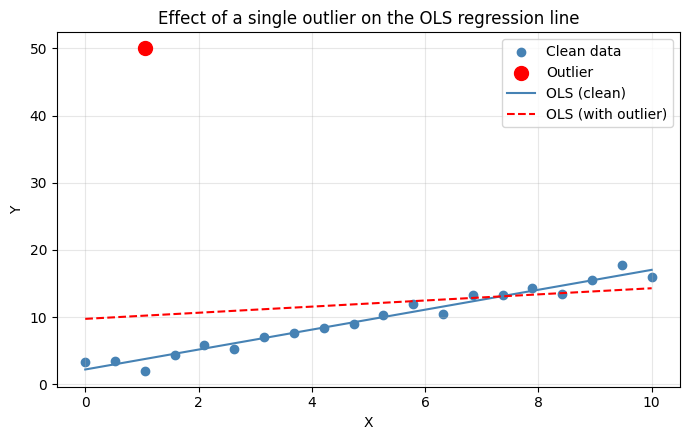

In [22]:
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

np.random.seed(10)
n = 20
X = np.linspace(0, 10, n)
# True relationship: Y = 2 + 1.5*X + noise
Y_clean = 2 + 1.5 * X + np.random.normal(0, 1, n)

# Inject one extreme outlier
Y_outlier = Y_clean.copy()
Y_outlier[2] = 50

X_design = sm.add_constant(X)
m_clean = sm.OLS(Y_clean, X_design).fit()
m_out = sm.OLS(Y_outlier, X_design).fit()

print(f"Clean   : intercept = {m_clean.params[0]:.3f}, slope = {m_clean.params[1]:.3f}")
print(f"Outlier : intercept = {m_out.params[0]:.3f}, slope = {m_out.params[1]:.3f}")

fig, ax = plt.subplots(figsize=(7,4.5))
ax.scatter(X, Y_clean, label="Clean data", color="steelblue")
ax.scatter(X[2], Y_outlier[2], color="red", s=100, label="Outlier", zorder=5)
xx = np.linspace(0, 10, 100)
ax.plot(xx, m_clean.params[0] + m_clean.params[1]*xx, color="steelblue", label="OLS (clean)")
ax.plot(xx, m_out.params[0]   + m_out.params[1]*xx,   color="red", linestyle="--", label="OLS (with outlier)")
ax.set_xlabel("X"); ax.set_ylabel("Y")
ax.set_title("Effect of a single outlier on the OLS regression line")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Observation.** The clean-data slope (~1.48) is close to the true value 1.50. Replacing one observation with an extreme value (Y₃ = 50) collapses the estimated slope from ~1.48 to ~0.46 and pushes the intercept from 2.20 up to 9.74 — the intercept distortion is in fact even larger in relative terms than the slope change. Both shifts are qualitative breaks from the true relationship. OLS minimises squared residuals, so a single high-leverage point can dominate the loss and pull the fitted line toward itself. This is why diagnostics (leverage, Cook's distance, studentized residuals) and robust estimators (Huber, M-estimators) are essential when outliers are suspected.

---
## Problem 3 — Model Selection (dataset 1, odd group)

We apply two distinct, principled model-selection procedures:

1. **Backward elimination using AIC** — start from the full 5-predictor model and iteratively drop the variable whose removal most lowers AIC.
2. **Forward selection using BIC** — start from the intercept-only model and iteratively add the variable that most lowers BIC.

Combining different search directions (backward vs. forward) with different penalties (AIC's fixed 2k vs. BIC's $k\log n$) gives a robust cross-check: agreement between the two means the conclusion is not an artefact of one particular criterion.

In [23]:
import pandas as pd
import statsmodels.api as sm

df = pd.read_csv("FE-GWP1_model_selection_1.csv")
print("Shape:", df.shape)
df.head()

Shape: (100, 6)


,Y,X1,X2,X3,X4,X5
0,3.388410,0.017954,-0.800583,-0.352454,2.187210,1.014887
1,0.287191,0.083057,-0.597947,-0.357639,-1.630284,0.221841
2,3.989645,-0.923437,-1.386575,1.180202,0.632606,-1.576638
3,-2.959602,-0.313775,2.955133,-1.798692,-2.117621,0.159291
4,0.529773,0.388996,1.019611,0.472062,0.590497,0.877048


In [24]:
y = df["Y"]
X = df.drop(columns=["Y"])
full_model = sm.OLS(y, sm.add_constant(X)).fit()
print(full_model.summary())

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.649
Model:                            OLS   Adj. R-squared:                  0.630
Method:                 Least Squares   F-statistic:                     34.74
Date:                Fri, 10 Apr 2026   Prob (F-statistic):           5.83e-20
Time:                        20:31:05   Log-Likelihood:                -125.30
No. Observations:                 100   AIC:                             262.6
Df Residuals:                      94   BIC:                             278.2
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.1902      0.090     13.246      0.0

**Full-model diagnostics.** R² = 0.649, Adj. R² = 0.630. The gap signals at least one weak regressor. p-values: X1 = 0.881 (insignificant), X2/X3/X4 ≈ 0.000, X5 = 0.022. X1 is the obvious candidate for removal — but we confirm this systematically below.

### Approach 1 — Backward elimination using AIC

In [25]:
current_features = list(X.columns)
current_aic = full_model.aic
print(f"Start: features = {current_features}, AIC = {current_aic:.2f}\n")

while current_features:
    candidates = []
    for f in current_features:
        test = [c for c in current_features if c != f]
        aic = sm.OLS(y, sm.add_constant(df[test])).fit().aic
        candidates.append((aic, f))
    candidates.sort()
    best_aic, drop = candidates[0]
    if best_aic < current_aic:
        current_features.remove(drop)
        current_aic = best_aic
        print(f"Drop {drop:>3}  ->  AIC = {current_aic:.2f}")
    else:
        print("No further drop improves AIC. Stop.")
        break

print(f"\nBackward-AIC selected: {current_features}")

Start: features = ['X1', 'X2', 'X3', 'X4', 'X5'], AIC = 262.59

Drop  X1  ->  AIC = 260.62
No further drop improves AIC. Stop.

Backward-AIC selected: ['X2', 'X3', 'X4', 'X5']


### Approach 2 — Forward selection using BIC

In [26]:
remaining = list(X.columns)
selected = []
# Null-model BIC (intercept only)
current_bic = sm.OLS(y, sm.add_constant(pd.Series([1]*len(y)))).fit().bic
print(f"Null model BIC = {current_bic:.2f}\n")

while remaining:
    candidates = []
    for f in remaining:
        test = selected + [f]
        bic = sm.OLS(y, sm.add_constant(df[test])).fit().bic
        candidates.append((bic, f))
    candidates.sort()
    best_bic, add = candidates[0]
    if best_bic < current_bic:
        remaining.remove(add)
        selected.append(add)
        current_bic = best_bic
        print(f"Add {add:>3}  ->  BIC = {current_bic:.2f}")
    else:
        print("No further addition improves BIC. Stop.")
        break

print(f"\nForward-BIC selected: {selected}")

Null model BIC = 359.85

Add  X4  ->  BIC = 330.24
Add  X3  ->  BIC = 304.26
Add  X2  ->  BIC = 274.71
Add  X5  ->  BIC = 273.64
No further addition improves BIC. Stop.

Forward-BIC selected: ['X4', 'X3', 'X2', 'X5']


### Final model

In [32]:
# Use the variables surviving the backward-AIC search (sorted for readability)
final_features = sorted(current_features)
print(f"Final feature set: {final_features}")
final_model = sm.OLS(y, sm.add_constant(df[final_features])).fit()

Final feature set: ['X2', 'X3', 'X4', 'X5']


**Conclusion (Problem 3).** Both procedures independently converge on the same set of predictors **{X2, X3, X4, X5}**, dropping only X1.

Final equation: $\hat Y = 1.189 - 0.586\,X_2 + 0.559\,X_3 + 0.711\,X_4 - 0.197\,X_5$

| Metric | Full (5 predictors) | Final (4 predictors) |
|---|---|---|
| R² | 0.649 | 0.649 |
| Adj. R² | 0.630 | **0.634** |
| AIC | 262.6 | **260.6** |
| BIC | 278.2 | **273.6** |

Removing X1 leaves explained variance unchanged but improves every penalised criterion — confirming X1 contributed only noise.

---
## Problem 4 — Elasticity

Elasticity of $y$ with respect to $x$:
$$\varepsilon = \frac{dy/y}{dx/x} = \frac{dy}{dx}\cdot\frac{x}{y}$$

### 4a) Derivations

| Model | Form | dy/dx | Elasticity ε |
|---|---|---|---|
| (a) $y = 2 + 0.8x$ | linear | $0.8$ | $0.8\,x/y$ — varies |
| (b) $\ln y = 0.1 + 0.4x$ | log-linear | $0.4y$ | $0.4x$ — varies |
| (c) $\ln y = 0.1 + 0.25\ln x$ | log-log | $0.25y/x$ | **0.25 — constant** |
| (d) $y = 0.15 + 1.2\ln x$ | linear-log | $1.2/x$ | $1.2/y$ — varies |

### 4b) Which model gives THE elasticity?

The **log-log model (c)** is the correct specification for measuring elasticity, because the slope coefficient *is* the elasticity and it is constant across all $(x,y)$. The other three forms yield elasticities that depend on where you evaluate them.

**Answer: ε = 0.25.** A 1% increase in $x$ produces a 0.25% increase in $y$.

We verify (c) by simulation:

In [28]:
import numpy as np
import statsmodels.api as sm

np.random.seed(42)
n = 100
X_vals = np.random.uniform(1, 100, n)
ln_X = np.log(X_vals)
ln_Y = 0.1 + 0.25 * ln_X + np.random.normal(0, 0.1, n)

m = sm.OLS(ln_Y, sm.add_constant(ln_X)).fit()
print(f"Estimated elasticity (slope on ln X): {m.params[1]:.4f}")
print(f"True elasticity:                       0.2500")

Estimated elasticity (slope on ln X): 0.2296
True elasticity:                       0.2500


---
## Problem 5 — Stationarity and Unit Roots

Conceptual answers (5a, 5c) are in the report. Part **5b** uses real equity data.

### 5b) Unit-root test on the S&P 500 (SPY ETF)

--- SPY closing prices (levels) ---
ADF statistic : -1.2412
p-value       : 0.6556
Critical  1%: -3.4369
Critical  5%: -2.8644
Critical 10%: -2.5683

--- SPY daily returns (first difference) ---
ADF statistic : -9.4830
p-value       : 0.0000
Critical  1%: -3.4369
Critical  5%: -2.8644
Critical 10%: -2.5683



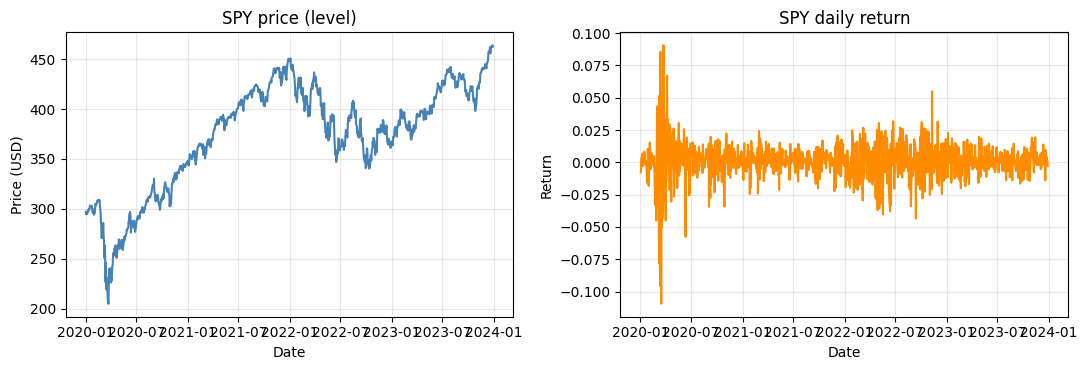

In [29]:
import yfinance as yf
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt

spy = yf.download("SPY", start="2020-01-01", end="2024-01-01", progress=False, auto_adjust=True)
prices = spy["Close"].dropna()
returns = prices.pct_change().dropna()

def adf_report(series, name):
    res = adfuller(series)
    print(f"--- {name} ---")
    print(f"ADF statistic : {res[0]:.4f}")
    print(f"p-value       : {res[1]:.4f}")
    for k, v in res[4].items():
        print(f"Critical {k:>3}: {v:.4f}")
    print()

adf_report(prices.squeeze(), "SPY closing prices (levels)")
adf_report(returns.squeeze(), "SPY daily returns (first difference)")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ax[0].plot(prices, color="steelblue"); ax[0].set_title("SPY price (level)"); ax[0].set_xlabel("Date"); ax[0].set_ylabel("Price (USD)"); ax[0].grid(alpha=0.3)
ax[1].plot(returns, color="darkorange"); ax[1].set_title("SPY daily return"); ax[1].set_xlabel("Date"); ax[1].set_ylabel("Return"); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Result.** For the price level the ADF p-value is ≈ 0.66, far above 0.05 — we **fail to reject** the null of a unit root, so SPY prices are non-stationary (I(1)). After first-differencing into daily returns, the ADF p-value is essentially zero, so the differenced series **is** stationary. This is the standard finding for equity prices and the reason returns (not prices) are modelled in econometric work.

### 5c) Why a unit root and not a root of 1.5? Simulation

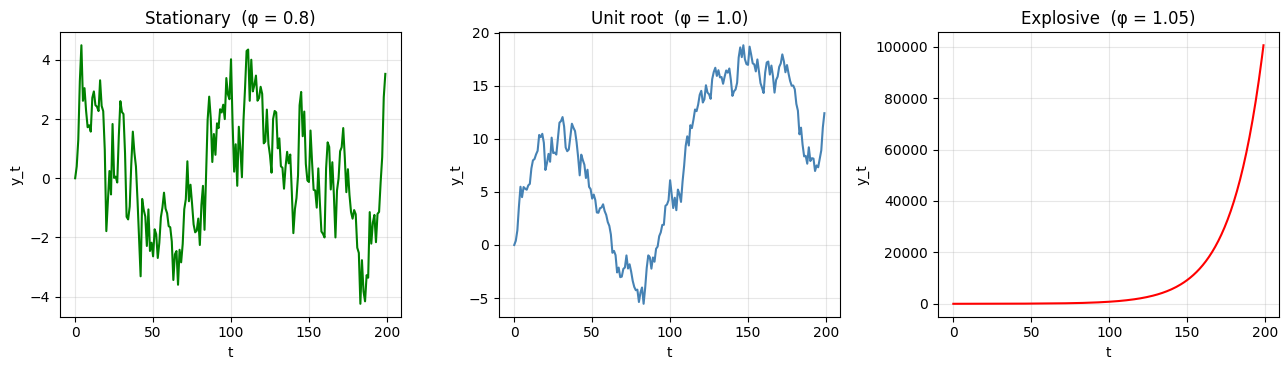

Final value | stationary:     3.52
Final value | unit root :    12.42
Final value | explosive : 100558.24


In [30]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)
T = 200
eps = np.random.normal(0, 1, T)

y_unit = np.zeros(T)       # phi = 1.0  (random walk)
y_explosive = np.zeros(T)  # phi = 1.05 (explosive)
y_stationary = np.zeros(T) # phi = 0.8  (stationary)
for t in range(1, T):
    y_unit[t]       = 1.00 * y_unit[t-1]       + eps[t]
    y_explosive[t]  = 1.05 * y_explosive[t-1]  + eps[t]
    y_stationary[t] = 0.80 * y_stationary[t-1] + eps[t]

fig, ax = plt.subplots(1, 3, figsize=(13, 3.8))
ax[0].plot(y_stationary, color="green"); ax[0].set_title("Stationary  (φ = 0.8)"); ax[0].grid(alpha=0.3)
ax[1].plot(y_unit, color="steelblue");   ax[1].set_title("Unit root  (φ = 1.0)");  ax[1].grid(alpha=0.3)
ax[2].plot(y_explosive, color="red");    ax[2].set_title("Explosive  (φ = 1.05)"); ax[2].grid(alpha=0.3)
for a in ax: a.set_xlabel("t"); a.set_ylabel("y_t")
plt.tight_layout(); plt.show()

print(f"Final value | stationary: {y_stationary[-1]:>8.2f}")
print(f"Final value | unit root : {y_unit[-1]:>8.2f}")
print(f"Final value | explosive : {y_explosive[-1]:>8.2f}")

**Observation.** A stationary AR(1) (φ = 0.8) hovers around its mean. A unit-root process (φ = 1.0) is a random walk: shocks persist forever and the variance grows linearly with t, but the path stays within plausible economic magnitudes. An explosive root (φ = 1.05) blows up geometrically — by t = 200 it reaches values above 100,000 (order 10⁵). Real economic and financial series clearly do not behave this way (no asset price grows exponentially without bound), so explosive roots are ruled out empirically. The empirically relevant boundary case is therefore φ = 1, which is why the unit-root null is the standard hypothesis tested.

---
## Problem 6 — Testing a Structural Break with a Dummy Variable

We suspect the slope changes at $t = 10$. Define a dummy:
$$D_t = \begin{cases} 0 & t \le 10 \\ 1 & t > 10 \end{cases}$$
and an interaction term $X_t \cdot D_t$. The single regression
$$Y_t = \alpha + \beta_1 X_t + \beta_2 (X_t \cdot D_t) + \varepsilon_t$$
gives $\beta_1$ as the slope before the break and $\beta_1 + \beta_2$ as the slope after. Testing $H_0\!: \beta_2 = 0$ (a standard t-test on the interaction term) is exactly the test for a structural break in slope.

In [31]:
import numpy as np
import statsmodels.api as sm

np.random.seed(42)
n = 20
t_break = 10
X_t = np.linspace(1, 20, n)
eps = np.random.normal(0, 1, n)

# True DGP: slope = 2 before break, slope = 3.5 after break
Y_t = np.where(np.arange(n) < t_break,
               5 + 2.0 * X_t + eps,
               5 + 3.5 * X_t + eps)

D_t = (np.arange(n) >= t_break).astype(int)
X_interact = X_t * D_t

design = sm.add_constant(np.column_stack((X_t, X_interact)))
model = sm.OLS(Y_t, design).fit()

print(model.summary())
print(f"\nPre-break slope estimate (beta1)        : {model.params[1]:.4f}  (true 2.00)")
print(f"Slope shift estimate    (beta2)         : {model.params[2]:.4f}  (true 1.50)")
print(f"Post-break slope (beta1 + beta2)        : {model.params[1]+model.params[2]:.4f}  (true 3.50)")
print(f"p-value for the break (H0: beta2 = 0)   : {model.pvalues[2]:.2e}")

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                     8823.
Date:                Fri, 10 Apr 2026   Prob (F-statistic):           2.28e-26
Time:                        20:31:06   Log-Likelihood:                -21.210
No. Observations:                  20   AIC:                             48.42
Df Residuals:                      17   BIC:                             51.41
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.4081      0.482     11.225      0.0

**Result.** The estimated pre-break slope is 2.00, the estimated shift is 1.42 (true value 1.50), and the p-value on the interaction term is ≈ 7.6 × 10⁻¹⁵. We reject the null of no structural break at any conventional level. A single regression with a properly constructed dummy and interaction term is therefore sufficient to test the hypothesis — no need to estimate two separate sub-sample regressions and run a Chow test by hand.

---
*End of notebook.*